In [1]:
from glob import glob
from collections import Counter
from collections import defaultdict

import scanpy as sc
import matplotlib.pyplot as plt
import pandas as pd
import anndata as ad
import numpy as np
import scipy.sparse as sp
import seaborn as sns
import gseapy as gp
import gseapy.plot as gplot
import matplotlib
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['pdf.fonttype'] = 42  # TrueType fonts
matplotlib.rcParams['ps.fonttype'] = 42   # TrueType fonts
matplotlib.rcParams['axes.unicode_minus'] = False # Fix unicode symbols
matplotlib.rcParams['figure.figsize'] = (8.27, 11.69)
# matplotlib.rcParams['savefig.bbox'] = 'tight'
matplotlib.rcParams['savefig.bbox'] = None
matplotlib.rcParams['figure.constrained_layout.use'] = False


In [2]:
#!/usr/bin/env python3
"""
Complete Figure Generation Script for Advanced Materials Journal
PSNP Impact on PBMC scRNA-seq Analysis

This script generates ALL MAIN FIGURES (1-6) and ALL SUPPLEMENTARY FIGURES according to FIGURES.md specifications

"""

import logging
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.gridspec import GridSpec

# Try to import upsetplot
try:
    from upsetplot import UpSet, from_contents
except ImportError:
    logging.warning("upsetplot not found, installing...")
    import subprocess
    subprocess.check_call(['pip', 'install', 'upsetplot'])
    from upsetplot import UpSet, from_contents

# ============================================================
# LOGGING CONFIGURATION
# ============================================================

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    datefmt='%H:%M:%S'
)
logger = logging.getLogger(__name__)

# ============================================================
# SETUP AND CONFIGURATION
# ============================================================

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['figure.figsize'] = (8.27, 11.69)
# plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['savefig.bbox'] = None
plt.rcParams['figure.constrained_layout.use'] = False

# Output directory
FIG_DIR = Path('./fig')
FIG_DIR.mkdir(exist_ok=True)


# SAMPLE_COLORS = {
#     'sample_1': '#d01c8b', '40nm': '#d01c8b',
#     'sample_2': '#f1b6da', '200nm': '#f1b6da',
#     'sample_3': '#b8e186', 'Mix': '#b8e186',
#     'sample_4': '#4dac26', 'Untreated': '#4dac26', 'Control': '#4dac26'
# }
#3287be

SAMPLE_COLORS = {
    'sample_1': '#3287be', '40nm': '#3287be',
    'sample_2': '#f0b4dc', '200nm': '#f0b4dc',
    'sample_3': '#b9e187', 'Mix': '#b9e187',
    'sample_4': '#ff7d55', 'Untreated': '#4dac26', 'Control': '#ff7d55'
}

CELL_TYPE_COLORS = {
    'B cell': '#abd9e9',
    'CD4+ T cell': '#fdae61',
    'Cytotoxic T cell': '#2c7bb6',# '#ffffbf',
    'CD14+ monocyte': '#d7191c',
    'Natural killer cell': '#8856a7'
}

CELL_TYPE_SHORT_MAP = {
    'B cell': 'B cell',
    'CD4+ T cell': 'CD4+',
    'Cytotoxic T cell': 'CD8+',
    'CD14+ monocyte': 'Monocyte',
    'Natural killer cell': 'NK'
}

CELL_TYPE_SHORT_MAP_ALT = {
    'B cell': 'B cell',
    'CD4+ T cell': 'CD4+_T_cell',
    'Cytotoxic T cell': 'CD8+_T_cell',
    'CD14+ monocyte': 'Monocyte',
    'Natural killer cell': 'NK_cell'
}

REG_COLORS = {
    'Upregulated': '#d7191c',
    'Downregulated': '#2c7bb6',
    'Not Significant': '#B0B0B0'
}

SAMPLE_NAMES = {
    'sample_1': '40nm',
    'sample_2': '200nm',
    'sample_3': 'Mix',
    'sample_4': 'Control'
}

CELL_TYPE_ORDER = [
    'CD14+ monocyte',
    'B cell',
    'CD4+ T cell',
    'Cytotoxic T cell',
    'Natural killer cell'
]

samples = ['40nm', '200nm', 'Mix']

logger.info("Configuration loaded")
logger.info(f"Output directory: {FIG_DIR.absolute()}")

cmap = 'RdBu_r'
cell_type_col = 'CoDi_dist'  # Use CoDi_dist annotation as specified
sample_col = 'sample'
# ============================================================
# LOAD DATA
# ============================================================

logger.info("Loading differential expression and pathway enrichment results...")

# Load DE results
de_results_path = Path('./results/de_results_CoDi_dist.xlsx')
de_results = {}
if de_results_path.exists():
    logger.info(f"Loading DE results from {de_results_path}")
    excel_file = pd.ExcelFile(de_results_path)
    for sheet_name in excel_file.sheet_names:
        de_results[sheet_name] = excel_file.parse(sheet_name)
    logger.info(f"✓ Loaded {len(de_results)} DE result sheets")
else:
    logger.error(f"DE results file not found: {de_results_path}")
    raise FileNotFoundError(f"Required file not found: {de_results_path}")

# Load GSE results
gse_results_path = Path('../data/Pathways_KEGG_cleaned.xlsx')
gse_results = {}
if gse_results_path.exists():
    logger.info(f"Loading GSE results from {gse_results_path}")
    gse_file = pd.ExcelFile(gse_results_path)
    for sheet_name in gse_file.sheet_names:
        gse_results[sheet_name] = gse_file.parse(sheet_name)
    logger.info(f"✓ Loaded {len(gse_results)} GSE result sheets")
else:
    logger.warning(f"GSE results file not found: {gse_results_path}")


def get_condition_label(condition):
    """
    Convert condition code to human-readable label.
    """
    cond_map = {
        '40nm': '40 nm',
        '200nm': '200 nm',
        'Mix': 'MIX (40 + 200 nm)',
        'Control': 'Control'
    }
    return cond_map.get(condition, condition)

def get_gse_sheet_name(cell_type, condition):
    """
    Convert cell type and condition to GSE sheet name format.
    GSE sheets use format: CellType_sample_X
    e.g., "Monocyte_sample_1", "B_cell_sample_2"
    """
    ct_map = {
        'B cell': 'B_cell',
        'CD4+ T cell': 'CD4+_T_cell',
        'Cytotoxic T cell': 'Cytotoxic_T_cell',
        'CD14+ monocyte': 'Monocyte',
        'Natural killer cell': 'Natural_killer_cell'
    }

    # Condition to sample mapping
    cond_map = {
        '40nm': '40 nm',
        '200nm': '200 nm',
        'Mix': 'MIX (40 + 200 nm)',
    }

    ct_name = ct_map.get(cell_type, cell_type.replace(' ', '_'))
    sample_name = cond_map.get(condition, condition)
    return f"{ct_name}_{sample_name}"

# Helper function for sheet names
def get_sheet_name_fig2(cell_type, condition):
    ct_map = {
        'B cell': 'B_cell',
        'CD4+ T cell': 'CD4+_T_cell',
        'Cytotoxic T cell': 'Cytotoxic_T_cell',
        'CD14+ monocyte': 'CD14+_monocyte',
        'Natural killer cell': 'Natural_killer_cell'
    }
    cond_map = {'40nm': 'sample_1', '200nm': 'sample_2', 'Mix': 'sample_3'}
    return f"{ct_map.get(cell_type, cell_type.replace(' ', '_'))}_{cond_map[condition]}"

15:20:29 - INFO - Configuration loaded
15:20:29 - INFO - Output directory: /Users/vladimirk/repositories/nano/notebooks/fig
15:20:29 - INFO - Loading differential expression and pathway enrichment results...
15:20:29 - INFO - Loading DE results from results/de_results_CoDi_dist.xlsx
15:20:33 - INFO - ✓ Loaded 15 DE result sheets
15:20:33 - INFO - Loading GSE results from ../data/Pathways_KEGG_cleaned.xlsx
15:20:33 - INFO - ✓ Loaded 15 GSE result sheets


In [3]:
"""
Setup for Figures 4 & 5: load AnnData, load KEGG_2025 pathway library,
compute per-cell module scores from canonical KEGG gene sets, and provide
robust GSE-sheet + t-test helpers.

Global font is set to 12 pt and figure widths are constrained to 210 mm
(8.27 in) for single-column Nature-style layout.
"""
import warnings, json
warnings.filterwarnings('ignore')
from scipy import stats as scstats

# ---- Global font: 12 pt (Nature single-column ≤ 210 mm width) ----
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 12,
    'axes.titlesize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.titlesize': 12,
})

# ---- Robust GSE helpers (column names differ between sample sheets) ----
def gse_term_col(df):
    return 'KEGG Term' if 'KEGG Term' in df.columns else 'Term'

def gse_module_col(df):
    return 'Module' if 'Module' in df.columns else 'Name'

def gse_sheet_name(cell_type, condition):
    ct_map = {
        'B cell': 'B_cell',
        'CD4+ T cell': 'CD4+_T_cell',
        'Cytotoxic T cell': 'Cytotoxic_T_cell',
        'CD14+ monocyte': 'Monocyte',
        'Natural killer cell': 'Natural_killer_cell',
    }
    cond_map = {'40nm': 'sample_1', '200nm': 'sample_2', 'Mix': 'sample_3'}
    return f"{ct_map[cell_type]}_{cond_map[condition]}"

def lookup_pathway_nes_fdr(cell_type, condition, term):
    sheet = gse_sheet_name(cell_type, condition)
    if sheet not in gse_results:
        return (np.nan, np.nan)
    df = gse_results[sheet]
    tc = gse_term_col(df)
    matches = df[df[tc] == term]
    if len(matches) == 0:
        matches = df[df[tc].str.contains(term, case=False, na=False, regex=False)]
    if len(matches) == 0:
        return (np.nan, np.nan)
    row = matches.iloc[0]
    return (float(row['NES']), float(row['FDR q-val']))

# ---- KEGG 2025 pathway library used for module scoring (Panel 4B) ----
KEGG_LIB_PATH = Path('./results/KEGG_2025_pathways.json')
with open(KEGG_LIB_PATH) as f:
    KEGG_LIB = json.load(f)
logger.info(f"Loaded KEGG library: {len(KEGG_LIB)} pathways")

# ---- Load merged AnnData ----
ADATA_PATH = Path('../data/merged_codi.h5ad')
logger.info(f"Loading AnnData: {ADATA_PATH}")
adata = sc.read_h5ad(ADATA_PATH)
logger.info(f"  AnnData: {adata.shape[0]} cells x {adata.shape[1]} genes")
logger.info(f"  layers available: {list(adata.layers.keys())}")

TREAT_ORDER = ['Control', '40nm', '200nm', 'Mix']
adata.obs['treatment'] = adata.obs['sample'].map(SAMPLE_NAMES).astype(
    pd.CategoricalDtype(categories=TREAT_ORDER, ordered=True))
logger.info(f"  Treatments: {adata.obs['treatment'].value_counts().to_dict()}")

# ---- Build pathway-based gene sets for Panel 4B scoring ----
def kegg_union(pathways):
    """Union of gene lists from KEGG_LIB for the given pathway names."""
    out = set()
    for p in pathways:
        if p in KEGG_LIB:
            out.update(KEGG_LIB[p])
        else:
            logger.warning(f"KEGG pathway not found: {p!r}")
    return sorted(out)

METABOLISM_PATHWAYS = [
    'Oxidative phosphorylation',
    'Citrate cycle (TCA cycle)',
    'Pentose phosphate pathway',
    'Fatty acid elongation',
]
INFLAMMATION_PATHWAYS = [
    'TNF signaling pathway',
    'IL-17 signaling pathway',
    'Cytokine-cytokine receptor interaction',
]
metabolism_genes   = kegg_union(METABOLISM_PATHWAYS)
inflammation_genes = kegg_union(INFLAMMATION_PATHWAYS)
logger.info(f"  Metabolism gene set: {len(metabolism_genes)} genes "
            f"(in adata: {sum(g in adata.var_names for g in metabolism_genes)})")
logger.info(f"  Inflammation gene set: {len(inflammation_genes)} genes "
            f"(in adata: {sum(g in adata.var_names for g in inflammation_genes)})")

def safe_score(adata_in, genes, score_name):
    present = [g for g in genes if g in adata_in.var_names]
    if len(present) == 0:
        adata_in.obs[score_name] = 0.0
        return
    sc.tl.score_genes(adata_in, gene_list=present, score_name=score_name,
                      ctrl_size=min(200, max(20, len(present))),
                      random_state=0, use_raw=False)

# Figure 4 scores: KEGG-pathway-based
safe_score(adata, metabolism_genes,   'Metabolism_Path')
safe_score(adata, inflammation_genes, 'Inflammation_Path')

# Figure 5 scores
metabolic_capacity_genes = ['RPS6', 'RPL3', 'NDUFA4', 'UQCRQ', 'COX7B', 'FAU']
immune_competence_genes  = ['CD79A', 'CD79B', 'HLA-DRB1', 'HLA-DQA1', 'HLA-DRA',
                            'CD247', 'CD3D', 'CD3E']
safe_score(adata, metabolic_capacity_genes, 'Metabolic_Capacity')
safe_score(adata, immune_competence_genes,  'Immune_Competence')

logger.info("✓ Module scores computed")

# Subsets used by Figure 4/5
adata_mono = adata[adata.obs['CoDi_dist'] == 'CD14+ monocyte'].copy()
adata_b    = adata[adata.obs['CoDi_dist'] == 'B cell'].copy()
adata_cd4  = adata[adata.obs['CoDi_dist'] == 'CD4+ T cell'].copy()
logger.info(f"  Monocytes: {adata_mono.n_obs} cells")
logger.info(f"  B cells:   {adata_b.n_obs} cells")
logger.info(f"  CD4+ T:    {adata_cd4.n_obs} cells")

def get_gene_expr(adata_in, gene):
    if gene not in adata_in.var_names:
        return np.zeros(adata_in.n_obs)
    x = adata_in[:, gene].X
    return np.asarray(x.todense()).ravel() if sp.issparse(x) else np.asarray(x).ravel()

def get_raw_counts(adata_in, gene):
    """Raw UMI counts from adata.layers['counts']."""
    if gene not in adata_in.var_names:
        return np.zeros(adata_in.n_obs)
    if 'counts' in adata_in.layers:
        x = adata_in[:, gene].layers['counts']
    else:
        x = np.expm1(adata_in[:, gene].X)
    return np.asarray(x.todense()).ravel() if sp.issparse(x) else np.asarray(x).ravel()

def get_log2fc_vs_control(adata_in, gene):
    """Per-cell log2 fold change vs Control mean.
    adata.X is log1p (natural log) of normalised counts; subtracting the
    Control mean gives ln fold change, divided by ln(2) for log2 scale."""
    expr = get_gene_expr(adata_in, gene)
    ctrl_mask = (adata_in.obs['treatment'] == 'Control').values
    ctrl_mean = expr[ctrl_mask].mean() if ctrl_mask.any() else 0.0
    return (expr - ctrl_mean) / np.log(2)

def pval_to_stars(p):
    if p is None or np.isnan(p):
        return ''
    if p < 0.001:
        return '***'
    if p < 0.01:
        return '**'
    if p < 0.05:
        return '*'
    return 'ns'

def ttest_vs_control(values, treatments, ctrl_label='Control'):
    treatments = np.asarray(treatments)
    values     = np.asarray(values)
    ctrl_vals  = values[treatments == ctrl_label]
    out = {}
    for t in pd.unique(treatments):
        if t == ctrl_label:
            continue
        t_vals = values[treatments == t]
        if len(ctrl_vals) > 1 and len(t_vals) > 1:
            _, p = scstats.ttest_ind(ctrl_vals, t_vals, equal_var=False)
            out[str(t)] = float(p)
        else:
            out[str(t)] = np.nan
    return out

def boxplot_with_strip(ax, df_v, order, palette, max_strip=400):
    """Box plot with a low-alpha jittered strip plot of all (or subsampled)
    points in the background. Designed for raw UMI counts."""
    # Subsample per group so the strip stays readable
    parts = []
    for grp in order:
        sub = df_v[df_v['treat'] == grp]
        if len(sub) > max_strip:
            sub = sub.sample(n=max_strip, random_state=0)
        parts.append(sub)
    df_strip = pd.concat(parts, ignore_index=True)
    sns.stripplot(data=df_strip, x='treat', y='expr', order=order,
                  color='black', size=1.2, alpha=0.18, jitter=0.30,
                  ax=ax, linewidth=0)
    sns.boxplot(data=df_v, x='treat', y='expr', order=order,
                palette=palette, ax=ax, fliersize=0,
                width=0.55, linewidth=0.9,
                boxprops={'alpha': 0.85, 'edgecolor': 'black'},
                medianprops={'color': 'black', 'linewidth': 1.2},
                whiskerprops={'color': 'black', 'linewidth': 0.9},
                capprops={'color': 'black', 'linewidth': 0.9})


15:20:33 - INFO - Loaded KEGG library: 353 pathways
15:20:33 - INFO - Loading AnnData: ../data/merged_codi.h5ad
15:20:39 - INFO -   AnnData: 34078 cells x 20388 genes
15:20:39 - INFO -   layers available: ['counts']
15:20:39 - INFO -   Treatments: {'200nm': 12676, '40nm': 8729, 'Control': 6516, 'Mix': 6157}
15:20:39 - INFO -   Metabolism gene set: 223 genes (in adata: 165)
15:20:39 - INFO -   Inflammation gene set: 426 genes (in adata: 316)
15:20:46 - INFO - ✓ Module scores computed
15:20:48 - INFO -   Monocytes: 1704 cells
15:20:48 - INFO -   B cells:   2913 cells
15:20:48 - INFO -   CD4+ T:    22513 cells


# ============================================================
# FIGURE 4: Size-dependent and non-linear effects of PSNPs on monocytes
# ============================================================

Figure 4 visualizes the **Inflammatory–Metabolic Paradox** in CD14+ monocytes:
40 nm PSNPs trigger a metabolic collapse (OXPHOS / TCA / Ribosome down) on
top of an inflammatory alarm (TNF / IL-17 up), and the 40+200 nm Mix adopts
the severe 40 nm "metabolic crash" signature rather than an averaged phenotype.

- Panel A: Grouped pathway dot plot (Metabolic Engine vs Inflammatory Alarm × treatments)
- Panel B: "Paradox" scatter — per-cell Metabolic vs Inflammatory module scores
- Panel C: Violin plots — ATF4 (alarm), ATF3 (broken brake), COX7B, RPS6
- Panel D: Bar chart — NES of TNF signaling and OXPHOS across treatments (non-linearity)

15:20:48 - INFO - Creating Figure 4 (210 mm, 12 pt)...
15:20:48 - INFO -   Panel 4A: pathway dot plot
15:20:48 - INFO -   Panel 4B: per-cell pathway-score scatter (stretched x-axis)
15:20:48 - INFO -   Panel 4C: box+strip plots (log2 fold change vs Control; per-gene y-axis)
15:20:49 - INFO - maxp pruned
15:20:49 - INFO - LTSH dropped
15:20:49 - INFO - cmap pruned
15:20:49 - INFO - kern dropped
15:20:49 - INFO - post pruned
15:20:49 - INFO - PCLT dropped
15:20:49 - INFO - GPOS pruned
15:20:49 - INFO - GSUB pruned
15:20:49 - INFO - JSTF dropped
15:20:49 - INFO - DSIG dropped
15:20:49 - INFO - name pruned
15:20:49 - INFO - glyf pruned
15:20:49 - INFO - Added gid0 to subset
15:20:49 - INFO - Added first four glyphs to subset
15:20:49 - INFO - Closing glyph list over 'GSUB': 40 glyphs before
15:20:49 - INFO - Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'F', 'I', 'M', 'O', 'P', 'R', 'S', 'T', 'X', 'a', 'asterisk', 'b', 'c', 'e', 'f', 'four', 'h', 'i', 'k', 'l', 'm', 'n', 'nonmarkingretu

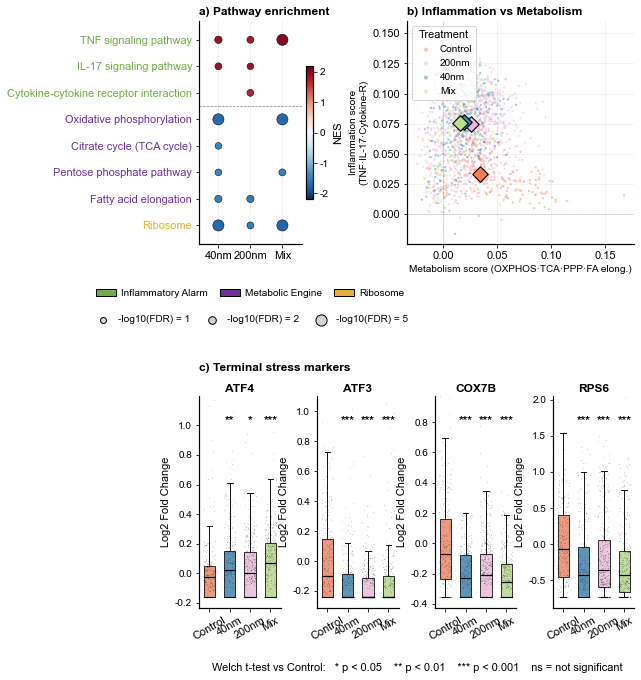

In [4]:
"""
FIGURE 4 (≤ 210 mm width, 12 pt font)
- Panel A: pathway dot plot (Inflammation top, Metabolism bottom; Ribosome
           label coloured #ebae34). Two stacked legends below: pathway-group
           colours (row 1) and -log10(FDR) size scale (row 2).
- Panel B: per-cell paradox scatter with x-axis physically stretched ~2×
           (Metabolism = OXPHOS+TCA+Pentose Phosphate+Fatty acid elongation;
            Inflammation = TNF+IL-17+Cytokine-cytokine receptor interaction).
- Panel C: box plots with strip plot in the background, raw UMI counts for
           ATF4/ATF3/COX7B/RPS6. INDEPENDENT y-axis per gene so small-range
           genes are not flattened. Welch t-test stars above each non-control
           box; one-line significance key below.
"""
logger.info("Creating Figure 4 (210 mm, 12 pt)...")

FIG_W = 7.8
fig4 = plt.figure(figsize=(FIG_W, 10.8)) 
# width_ratios stretch panel B ~2× the previous size, with wspace = 0.55
# adding extra horizontal breathing room between A and B.
gs4 = fig4.add_gridspec(2, 2, hspace=0.70, wspace=0.55,
                        height_ratios=[1.05, 1.00], width_ratios=[1.0, 2.0])

GROUP_COLORS = {
    'Inflammatory Alarm': '#70AD47',
    'Metabolic Engine':   '#7030A0',
}
RIBOSOME_COLOR = '#ebae34'

# ============================================================
# Panel A: Pathway dot plot — inflammation on top, metabolism below
# ============================================================
logger.info("  Panel 4A: pathway dot plot")

panel_a_pathways = [
    ('Inflammatory Alarm', 'TNF signaling pathway'),
    ('Inflammatory Alarm', 'IL-17 signaling pathway'),
    ('Inflammatory Alarm', 'Cytokine-cytokine receptor interaction'),
    ('Metabolic Engine',  'Oxidative phosphorylation'),
    ('Metabolic Engine',  'Citrate cycle (TCA cycle)'),
    ('Metabolic Engine',  'Pentose phosphate pathway'),
    ('Metabolic Engine',  'Fatty acid elongation'),
    ('Metabolic Engine',  'Ribosome'),
]

dot_x, dot_y, dot_nes, dot_logfdr = [], [], [], []
y_labels, y_groups = [], []
for i, (grp, term) in enumerate(panel_a_pathways):
    y_labels.append(term)
    y_groups.append(grp)
    for j, cond in enumerate(samples):
        nes, fdr = lookup_pathway_nes_fdr('CD14+ monocyte', cond, term)
        if not np.isnan(nes):
            dot_x.append(j); dot_y.append(i)
            dot_nes.append(nes)
            dot_logfdr.append(min(5.0, -np.log10(max(fdr, 1e-5))))

ax_a = fig4.add_subplot(gs4[0, 0])
size_scale = 22
sc_a = ax_a.scatter(dot_x, dot_y, s=[v*size_scale + 14 for v in dot_logfdr],
                    c=dot_nes, cmap='RdBu_r', vmin=-2.2, vmax=2.2,
                    edgecolors='black', linewidths=0.5, zorder=3)

ax_a.set_yticks(range(len(y_labels)))
ax_a.set_yticklabels(y_labels, fontsize=11)
for tick, term, grp in zip(ax_a.get_yticklabels(), y_labels, y_groups):
    if term == 'Ribosome':
        tick.set_color(RIBOSOME_COLOR)
    else:
        tick.set_color(GROUP_COLORS[grp])

n_inflam = sum(1 for g in y_groups if g == 'Inflammatory Alarm')
ax_a.axhline(n_inflam - 0.5, color='black', linewidth=0.7,
             linestyle='--', alpha=0.5)

ax_a.set_xticks(range(len(samples)))
ax_a.set_xticklabels(samples, fontsize=11)
ax_a.set_xlim(-0.6, len(samples) - 0.4)
ax_a.set_ylim(-0.7, len(y_labels) - 0.3)
ax_a.invert_yaxis()
ax_a.grid(True, axis='x', alpha=0.2)
for spine in ['top', 'right']:
    ax_a.spines[spine].set_visible(False)

cbar_a = plt.colorbar(sc_a, ax=ax_a, fraction=0.06, pad=0.04, shrink=0.6)
cbar_a.set_label('NES', fontsize=11)
cbar_a.ax.tick_params(labelsize=10)

# Two stacked legends below panel A:
#   row 1 — pathway-group colours (one line)
#   row 2 — dot-size scale (one line)
group_handles = [
    Patch(facecolor=GROUP_COLORS['Inflammatory Alarm'],
          edgecolor='black', label='Inflammatory Alarm'),
    Patch(facecolor=GROUP_COLORS['Metabolic Engine'],
          edgecolor='black', label='Metabolic Engine'),
    Patch(facecolor=RIBOSOME_COLOR, edgecolor='black', label='Ribosome'),
]
leg_groups = ax_a.legend(handles=group_handles,
                         loc='upper center', bbox_to_anchor=(0.5, -0.16),
                         fontsize=10, frameon=False, ncol=3,
                         handletextpad=0.5, columnspacing=1.2)
ax_a.add_artist(leg_groups)

size_legend_vals = [1, 2, 5]
size_handles = [plt.scatter([], [], s=v*size_scale + 14,
                            c='lightgray', edgecolors='black',
                            label=f'-log10(FDR) = {v}')
                for v in size_legend_vals]
ax_a.legend(handles=size_handles,
            loc='upper center', bbox_to_anchor=(0.5, -0.28),
            fontsize=10, frameon=False, ncol=3,
            handletextpad=0.5, columnspacing=1.2)

ax_a.set_title('a) Pathway enrichment',
               loc='left', fontsize=12, fontweight='bold', pad=6)

# ============================================================
# Panel B: Inflammation vs Metabolism scatter (stretched ~2× horizontally)
# ============================================================
logger.info("  Panel 4B: per-cell pathway-score scatter (stretched x-axis)")

ax_b = fig4.add_subplot(gs4[0, 1])

obs_mono = adata_mono.obs.copy()
plot_order = ['Control', '200nm', '40nm', 'Mix']
for treat in plot_order:
    sub = obs_mono[obs_mono['treatment'] == treat]
    ax_b.scatter(sub['Metabolism_Path'], sub['Inflammation_Path'],
                 c=SAMPLE_COLORS.get(treat, 'gray'),
                 s=5, alpha=0.45, label=treat,
                 edgecolors='none', rasterized=True)

for treat in plot_order:
    sub = obs_mono[obs_mono['treatment'] == treat]
    if len(sub) == 0:
        continue
    mx = sub['Metabolism_Path'].median()
    my = sub['Inflammation_Path'].median()
    ax_b.scatter([mx], [my], c=SAMPLE_COLORS.get(treat, 'gray'),
                 s=120, marker='D', edgecolors='black', linewidths=1.1,
                 zorder=5)

ax_b.axhline(0, color='gray', linestyle='--', linewidth=0.6, alpha=0.5)
ax_b.axvline(0, color='gray', linestyle='--', linewidth=0.6, alpha=0.5)
ax_b.set_xlabel('Metabolism score (OXPHOS·TCA·PPP·FA elong.)', fontsize=10)
ax_b.set_ylabel('Inflammation score\n(TNF·IL-17·Cytokine-R)', fontsize=10)
ax_b.tick_params(axis='both', labelsize=11)
ax_b.legend(loc='upper left', fontsize=10, frameon=True, title='Treatment',
            title_fontsize=11, markerscale=1.8, handletextpad=0.4)
for spine in ['top', 'right']:
    ax_b.spines[spine].set_visible(False)
ax_b.grid(True, alpha=0.2)
ax_b.set_title('b) Inflammation vs Metabolism',
               loc='left', fontsize=12, fontweight='bold', pad=6)

# ============================================================
# Panel C: Box plot + strip plot of raw UMI counts (ATF4 / ATF3 / COX7B / RPS6)
# Independent y-axis per gene (no longer shared).
# ============================================================
logger.info("  Panel 4C: box+strip plots (log2 fold change vs Control; per-gene y-axis)")

violin_genes_4c = ['ATF4', 'ATF3', 'COX7B', 'RPS6']
violin_counts = {g: get_log2fc_vs_control(adata_mono, g) for g in violin_genes_4c}
treat_arr_mono = np.asarray(adata_mono.obs['treatment'].values)

gs_c = gs4[1, :].subgridspec(1, len(violin_genes_4c), wspace=0.45)
axes_c4 = []
for k, gene in enumerate(violin_genes_4c):
    ax = fig4.add_subplot(gs_c[0, k])
    axes_c4.append(ax)

    df_v = pd.DataFrame({
        'expr': violin_counts[gene],
        'treat': treat_arr_mono,
    })
    df_v['treat'] = pd.Categorical(df_v['treat'],
                                   categories=TREAT_ORDER, ordered=True)
    palette = [SAMPLE_COLORS.get(t, 'gray') for t in TREAT_ORDER]

    boxplot_with_strip(ax, df_v, TREAT_ORDER, palette, max_strip=350)

    g_lo = np.percentile(violin_counts[gene], 1)
    g_hi = np.percentile(violin_counts[gene], 99)
    g_span = max(g_hi - g_lo, 0.5)
    y_lo_g = g_lo - 0.08 * g_span
    y_hi_g = g_hi + 0.40 * g_span
    star_y_g = g_hi + 0.20 * g_span
    ax.set_ylim(y_lo_g, y_hi_g)

    ax.set_title(gene, fontsize=12, fontweight='bold', pad=4)
    ax.set_xlabel('')
    ax.set_ylabel('Log2 Fold Change', fontsize=11)
    ax.tick_params(axis='x', rotation=30, labelsize=11)
    ax.tick_params(axis='y', labelsize=10)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    pvals = ttest_vs_control(violin_counts[gene], treat_arr_mono,
                             ctrl_label='Control')
    for ti, t in enumerate(TREAT_ORDER):
        if t == 'Control':
            continue
        stars = pval_to_stars(pvals.get(t, np.nan))
        if stars:
            ax.text(ti, star_y_g, stars, ha='center', va='bottom',
                    fontsize=12, fontweight='bold', color='black')

first_bbox_4 = axes_c4[0].get_position()
last_bbox_4  = axes_c4[-1].get_position()
fig4.text(first_bbox_4.x0, first_bbox_4.y1 + 0.03,
          'c) Terminal stress markers',
          fontsize=12, fontweight='bold', ha='left', va='bottom')
fig4.text((first_bbox_4.x0 + last_bbox_4.x1) / 2,
          first_bbox_4.y0 - 0.07,
          'Welch t-test vs Control:   * p < 0.05    ** p < 0.01    '
          '*** p < 0.001    ns = not significant',
          fontsize=11, ha='center', va='top')

plt.savefig(FIG_DIR / 'Figure_4_monocyte_paradox.pdf',
            bbox_inches='tight', dpi=300)
plt.savefig(FIG_DIR / 'Figure_4_monocyte_paradox.png',
            bbox_inches='tight', dpi=200)
logger.info("✓ Figure 4 complete\n")
plt.show()

# ============================================================
# FIGURE 5: Immunological Isolation in adaptive immune cells (B cells & CD4+ T cells)
# ============================================================

Adaptive cells stay metabolically active (Ribosome / OXPHOS up) but lose
communication capacity (BCR / Antigen-processing / Cell-adhesion down),
with the deepest collapse in the 40+200 nm Mix. Net effect: the adaptive
compartment is "online but isolated" — protein-ready bystanders that
cannot recognise or coordinate against the threat.

- Panel A: Grouped pathway dot plot (Ribosome/OXPHOS up vs BCR/Antigen-processing down) for B and CD4+ T across 40, 200, Mix
- Panel B: "Adaptive Anergy" scatter — Metabolic Capacity vs Immune Competence per cell (B + CD4+ T)
- Panel C: Violin plots — Ribosomal (RPS6, RPL3), BCR complex (CD79A, CD79B, CD22), MHC-II (HLA-DRB1, HLA-DQA1, HLA-DRA) in B cells (per-cell log2FC vs Control)

15:20:51 - INFO - Creating Figure 5 (210 mm, 12 pt)...
15:20:51 - INFO -   Panel 5A: pathway dot plot for adaptive cells
15:20:51 - INFO -   Panel 5B: Adaptive Anergy scatter
15:20:51 - INFO -   Panel 5C: box+strip plots in B cells (log2 fold change vs Control; per-gene y)
15:20:53 - INFO - maxp pruned
15:20:53 - INFO - LTSH dropped
15:20:53 - INFO - cmap pruned
15:20:53 - INFO - kern dropped
15:20:53 - INFO - post pruned
15:20:53 - INFO - PCLT dropped
15:20:53 - INFO - GPOS pruned
15:20:53 - INFO - GSUB pruned
15:20:53 - INFO - JSTF dropped
15:20:53 - INFO - DSIG dropped
15:20:53 - INFO - name pruned
15:20:53 - INFO - glyf pruned
15:20:53 - INFO - Added gid0 to subset
15:20:53 - INFO - Added first four glyphs to subset
15:20:53 - INFO - Closing glyph list over 'GSUB': 47 glyphs before
15:20:53 - INFO - Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'D', 'H', 'L', 'P', 'Q', 'R', 'S', 'T', 'a', 'asterisk', 'b', 'c', 'd', 'e', 'four', 'g', 'h', 'hyphen', 'i', 'k', 'l', 'm', 'n', 'nine'

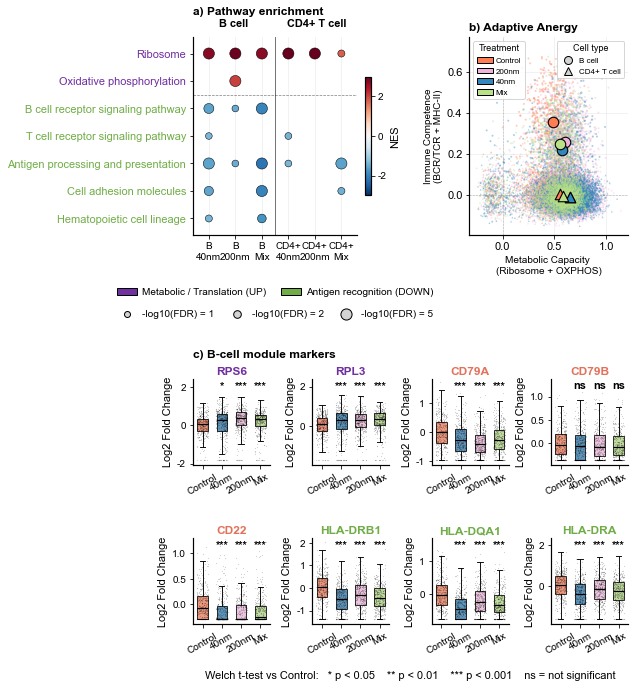

In [5]:
"""
FIGURE 5 (≤ 210 mm width, 12 pt font)
- Panel A: pathway dot plot — B cells and CD4+ T cells across 3 treatments,
           split into Metabolic / Translation (UP) and Antigen recognition
           (DOWN) groups. Two stacked legends below: pathway-group colours
           (row 1) and -log10(FDR) size scale (row 2).
- Panel B: "Adaptive Anergy" per-cell scatter — Metabolic Capacity vs Immune
           Competence (B cells + CD4+ T cells).
- Panel C: box plots with strip plot in the background of raw UMI counts for
           8 B-cell genes (Ribosomal / BCR / MHC-II). INDEPENDENT y-axis per
           gene. Welch t-test stars above each non-control box; one-line
           significance key below.
"""
logger.info("Creating Figure 5 (210 mm, 12 pt)...")

FIG_W = 7.8
fig5 = plt.figure(figsize=(FIG_W, 10.8))
# Increase wspace to put more horizontal breathing room between A and B.
gs5 = fig5.add_gridspec(2, 2, hspace=0.65, wspace=0.55,
                        height_ratios=[1.05, 1.30], width_ratios=[1.15, 1.00])

GROUP_COLORS_5 = {
    'Metabolic / Translation (UP)': '#7030A0',
    'Antigen recognition (DOWN)':   '#70AD47',
}

# ============================================================
# Panel A: Pathway dot plot (B cells & CD4+ T cells)
# ============================================================
logger.info("  Panel 5A: pathway dot plot for adaptive cells")

panel_a_groups = [
    ('Metabolic / Translation (UP)',  'Ribosome'),
    ('Metabolic / Translation (UP)',  'Oxidative phosphorylation'),
    ('Antigen recognition (DOWN)',    'B cell receptor signaling pathway'),
    ('Antigen recognition (DOWN)',    'T cell receptor signaling pathway'),
    ('Antigen recognition (DOWN)',    'Antigen processing and presentation'),
    ('Antigen recognition (DOWN)',    'Cell adhesion molecules'),
    ('Antigen recognition (DOWN)',    'Hematopoietic cell lineage'),
]
adaptive_ct = [('B cell', 'B'), ('CD4+ T cell', 'CD4+')]
x_columns = [(ct_full, cond, f'{ct_short}\n{cond}')
             for ct_full, ct_short in adaptive_ct for cond in samples]

dot_x, dot_y, dot_nes, dot_logfdr = [], [], [], []
y_labels = [t for _, t in panel_a_groups]
y_groups = [g for g, _ in panel_a_groups]
for j, (ct_full, cond, _) in enumerate(x_columns):
    for i, (_, term) in enumerate(panel_a_groups):
        nes, fdr = lookup_pathway_nes_fdr(ct_full, cond, term)
        if not np.isnan(nes):
            dot_x.append(j); dot_y.append(i)
            dot_nes.append(nes)
            dot_logfdr.append(min(5.0, -np.log10(max(fdr, 1e-5))))

ax_a = fig5.add_subplot(gs5[0, 0])
size_scale = 22
sc_a = ax_a.scatter(dot_x, dot_y, s=[v*size_scale + 14 for v in dot_logfdr],
                    c=dot_nes, cmap='RdBu_r', vmin=-3.0, vmax=3.0,
                    edgecolors='black', linewidths=0.5, zorder=3)

ax_a.set_yticks(range(len(y_labels)))
ax_a.set_yticklabels(y_labels, fontsize=11)
for tick, grp in zip(ax_a.get_yticklabels(), y_groups):
    tick.set_color(GROUP_COLORS_5[grp])

n_up = sum(1 for g in y_groups if g == 'Metabolic / Translation (UP)')
ax_a.axhline(n_up - 0.5, color='black', linewidth=0.7,
             linestyle='--', alpha=0.5)

ax_a.set_xticks(range(len(x_columns)))
ax_a.set_xticklabels([lbl for _, _, lbl in x_columns], fontsize=10)
ax_a.set_xlim(-0.6, len(x_columns) - 0.4)
ax_a.set_ylim(-0.6, len(y_labels) - 0.4)
ax_a.invert_yaxis()
ax_a.grid(True, axis='x', alpha=0.2)
for spine in ['top', 'right']:
    ax_a.spines[spine].set_visible(False)

ax_a.axvline(len(samples) - 0.5, color='black', linewidth=0.9,
             linestyle='-', alpha=0.6)
ax_a.text(0.25, 1.04, 'B cell', transform=ax_a.transAxes,
          ha='center', va='bottom', fontsize=11, fontweight='bold')
ax_a.text(0.75, 1.04, 'CD4+ T cell', transform=ax_a.transAxes,
          ha='center', va='bottom', fontsize=11, fontweight='bold')

cbar_a = plt.colorbar(sc_a, ax=ax_a, fraction=0.06, pad=0.04, shrink=0.6)
cbar_a.set_label('NES', fontsize=11)
cbar_a.ax.tick_params(labelsize=10)

# Two stacked legends below panel A:
#   row 1 — pathway-group colours
#   row 2 — dot-size scale
group_handles_5 = [
    Patch(facecolor=GROUP_COLORS_5['Metabolic / Translation (UP)'],
          edgecolor='black', label='Metabolic / Translation (UP)'),
    Patch(facecolor=GROUP_COLORS_5['Antigen recognition (DOWN)'],
          edgecolor='black', label='Antigen recognition (DOWN)'),
]
leg_groups_5 = ax_a.legend(handles=group_handles_5,
                           loc='upper center', bbox_to_anchor=(0.5, -0.22),
                           fontsize=10, frameon=False, ncol=2,
                           handletextpad=0.5, columnspacing=1.5)
ax_a.add_artist(leg_groups_5)

size_legend_vals = [1, 2, 5]
size_handles_5 = [plt.scatter([], [], s=v*size_scale + 14,
                              c='lightgray', edgecolors='black',
                              label=f'-log10(FDR) = {v}')
                  for v in size_legend_vals]
ax_a.legend(handles=size_handles_5,
            loc='upper center', bbox_to_anchor=(0.5, -0.33),
            fontsize=10, frameon=False, ncol=3,
            handletextpad=0.5, columnspacing=1.2)

ax_a.set_title('a) Pathway enrichment',
               loc='left', fontsize=12, fontweight='bold', pad=22)

# ============================================================
# Panel B: Adaptive Anergy scatter (B + CD4+ T)
# ============================================================
logger.info("  Panel 5B: Adaptive Anergy scatter")

ax_b = fig5.add_subplot(gs5[0, 1])
plot_order = ['Control', '200nm', '40nm', 'Mix']

for ct_full, marker in [('B cell', 'o'), ('CD4+ T cell', '^')]:
    sub_ad = adata[adata.obs['CoDi_dist'] == ct_full]
    obs = sub_ad.obs
    for treat in plot_order:
        sel = obs[obs['treatment'] == treat]
        ax_b.scatter(sel['Metabolic_Capacity'], sel['Immune_Competence'],
                     c=SAMPLE_COLORS.get(treat, 'gray'),
                     marker=marker, s=4, alpha=0.40,
                     edgecolors='none', rasterized=True)

for ct_full, marker in [('B cell', 'o'), ('CD4+ T cell', '^')]:
    sub_ad = adata[adata.obs['CoDi_dist'] == ct_full]
    obs = sub_ad.obs
    for treat in plot_order:
        sel = obs[obs['treatment'] == treat]
        if len(sel) == 0:
            continue
        mx = sel['Metabolic_Capacity'].median()
        my = sel['Immune_Competence'].median()
        ax_b.scatter([mx], [my],
                     c=SAMPLE_COLORS.get(treat, 'gray'),
                     marker=marker, s=110,
                     edgecolors='black', linewidths=1.1, zorder=5)

ax_b.axhline(0, color='gray', linestyle='--', linewidth=0.6, alpha=0.5)
ax_b.axvline(0, color='gray', linestyle='--', linewidth=0.6, alpha=0.5)
ax_b.set_xlabel('Metabolic Capacity \n(Ribosome + OXPHOS)', fontsize=10)
ax_b.set_ylabel('Immune Competence\n(BCR/TCR + MHC-II)', fontsize=10)
ax_b.tick_params(axis='both', labelsize=11)

legend_treat = [Patch(facecolor=SAMPLE_COLORS.get(t, 'gray'),
                      edgecolor='black', label=t) for t in plot_order]
legend_ct = [
    plt.Line2D([0], [0], marker='o', linestyle='None', color='black',
               markerfacecolor='lightgray', markersize=8, label='B cell'),
    plt.Line2D([0], [0], marker='^', linestyle='None', color='black',
               markerfacecolor='lightgray', markersize=8, label='CD4+ T cell'),
]
leg1 = ax_b.legend(handles=legend_treat, loc='upper left',
                   title='Treatment', fontsize=8, title_fontsize=9,
                   frameon=True, handletextpad=0.4)
ax_b.add_artist(leg1)
ax_b.legend(handles=legend_ct, loc='upper right',
            title='Cell type', fontsize=8, title_fontsize=9,
            frameon=True, handletextpad=0.4)

for spine in ['top', 'right']:
    ax_b.spines[spine].set_visible(False)
ax_b.grid(True, alpha=0.2)
ax_b.set_title('b) Adaptive Anergy',
               loc='left', fontsize=12, fontweight='bold', pad=6)

# ============================================================
# Panel C: Box plot + strip plot in B cells (Ribosomal / BCR / MHC-II)
# 2 rows × 4 cols (8 genes). Independent y-axis per gene.
# ============================================================
logger.info("  Panel 5C: box+strip plots in B cells (log2 fold change vs Control; per-gene y)")

violin_modules_5c = [
    ('Ribosomal',   ['RPS6', 'RPL3'],                    '#7030A0'),
    ('BCR complex', ['CD79A', 'CD79B', 'CD22'],          '#E2725B'),
    ('MHC-II',      ['HLA-DRB1', 'HLA-DQA1', 'HLA-DRA'], '#70AD47'),
]
all_genes_5c = [(g, color) for _, gs_, color in violin_modules_5c for g in gs_]
gene_color_map = dict(all_genes_5c)

violin_counts_5c = {g: get_log2fc_vs_control(adata_b, g) for g, _ in all_genes_5c}
treat_arr_b = np.asarray(adata_b.obs['treatment'].values)

gs_c = gs5[1, :].subgridspec(2, 4, hspace=0.85, wspace=0.55)

axes_c5 = []
for idx, (gene, mod_color) in enumerate(all_genes_5c):
    row, col = idx // 4, idx % 4
    ax = fig5.add_subplot(gs_c[row, col])
    axes_c5.append(ax)

    df_v = pd.DataFrame({
        'expr': violin_counts_5c[gene],
        'treat': treat_arr_b,
    })
    df_v['treat'] = pd.Categorical(df_v['treat'],
                                   categories=TREAT_ORDER, ordered=True)
    palette = [SAMPLE_COLORS.get(t, 'gray') for t in TREAT_ORDER]

    boxplot_with_strip(ax, df_v, TREAT_ORDER, palette, max_strip=350)

    g_lo = np.percentile(violin_counts_5c[gene], 1)
    g_hi = np.percentile(violin_counts_5c[gene], 99)
    g_span = max(g_hi - g_lo, 0.5)
    y_lo_g = g_lo - 0.08 * g_span
    y_hi_g = g_hi + 0.40 * g_span
    star_y_g = g_hi + 0.20 * g_span
    ax.set_ylim(y_lo_g, y_hi_g)

    ax.set_title(gene, fontsize=12, fontweight='bold', color=mod_color, pad=4)
    ax.set_xlabel('')
    ax.set_ylabel('Log2 Fold Change', fontsize=11)
    ax.tick_params(axis='x', rotation=30, labelsize=10)
    ax.tick_params(axis='y', labelsize=10)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    pvals = ttest_vs_control(violin_counts_5c[gene], treat_arr_b,
                             ctrl_label='Control')
    for ti, t in enumerate(TREAT_ORDER):
        if t == 'Control':
            continue
        stars = pval_to_stars(pvals.get(t, np.nan))
        if stars:
            ax.text(ti, star_y_g, stars, ha='center', va='bottom',
                    fontsize=11, fontweight='bold', color='black')

top_left_bbox  = axes_c5[0].get_position()
bot_right_bbox = axes_c5[-1].get_position()
fig5.text(top_left_bbox.x0, top_left_bbox.y1 + 0.025,
          'c) B-cell module markers',
          fontsize=12, fontweight='bold', ha='left', va='bottom')

legend_y = bot_right_bbox.y0 - 0.06
legend_x = (top_left_bbox.x0 + bot_right_bbox.x1) / 2
fig5.text(legend_x, legend_y,
          'Welch t-test vs Control:   * p < 0.05    ** p < 0.01    '
          '*** p < 0.001    ns = not significant',
          fontsize=11, ha='center', va='top')

plt.savefig(FIG_DIR / 'Figure_5_adaptive_isolation.pdf',
            bbox_inches='tight', dpi=300)
plt.savefig(FIG_DIR / 'Figure_5_adaptive_isolation.png',
            bbox_inches='tight', dpi=200)
logger.info("✓ Figure 5 complete\n")
plt.show()

# ============================================================
# SUPPLEMENTARY FIGURE A: Monocyte gene dot plot
# ============================================================

Gene-level dot plot for CD14+ monocytes across the three PSNP treatments
(40 nm, 200 nm, Mix) versus untreated Control. Genes are organised into
three functional categories:

- **Immunometabolic / mitochondrial adaptation** — ATF3, ATF4, COX7B, GPX3, SLC25A37, XBP1, HSP90B1, P4HB
- **Controlled inflammatory engagement** — IL1B, IL6, PTGS2, CCL20, IL24, CSF2, CSF3
- **Regulatory / inhibitory balancing** — SIGLEC7, FGL2, IL10

Dot colour encodes the per-gene log2 fold change from `rank_genes_groups`
(treatment vs Control); dot size encodes statistical significance as
`-log10(FDR q-value)`. Style matches the pathway dot plots in panels 4A and 5A.

15:20:55 - INFO - Creating Supplementary Figure A (monocyte gene dot plot)...
15:20:55 - INFO - maxp pruned
15:20:55 - INFO - LTSH dropped
15:20:55 - INFO - cmap pruned
15:20:55 - INFO - kern dropped
15:20:55 - INFO - post pruned
15:20:55 - INFO - PCLT dropped
15:20:55 - INFO - GPOS pruned
15:20:55 - INFO - GSUB pruned
15:20:55 - INFO - JSTF dropped
15:20:55 - INFO - DSIG dropped
15:20:55 - INFO - name pruned
15:20:55 - INFO - glyf pruned
15:20:55 - INFO - Added gid0 to subset
15:20:55 - INFO - Added first four glyphs to subset
15:20:55 - INFO - Closing glyph list over 'GSUB': 19 glyphs before
15:20:55 - INFO - Glyph names: ['.notdef', '.null', 'A', 'M', 'S', 'a', 'c', 'e', 'g', 'l', 'n', 'nonmarkingreturn', 'o', 'p', 'parenright', 'space', 't', 'u', 'y']
15:20:55 - INFO - Glyph IDs:   [0, 1, 2, 3, 12, 36, 48, 54, 68, 70, 72, 74, 79, 81, 82, 83, 87, 88, 92]
15:20:55 - INFO - Closed glyph list over 'GSUB': 19 glyphs after
15:20:55 - INFO - Glyph names: ['.notdef', '.null', 'A', 'M', 'S'

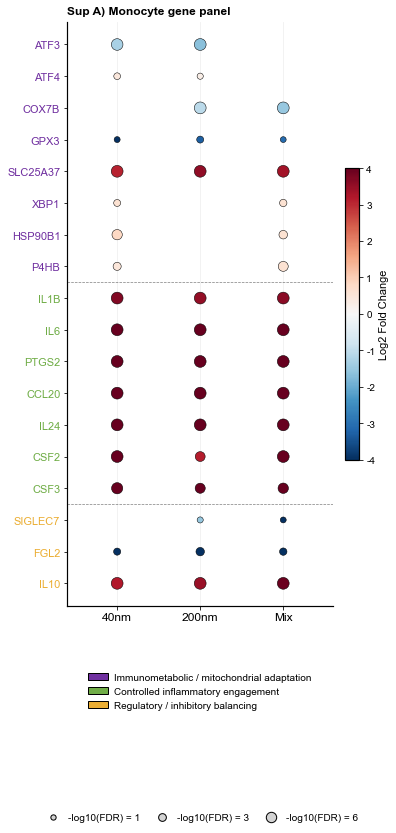

In [6]:
"""
SUPPLEMENTARY FIGURE A (≤ 210 mm width, 12 pt font)
- Single panel dot plot for CD14+ monocyte DE results across the three PSNP
  treatments. 18 genes grouped into three functional categories. Dot colour =
  log2 fold change (RdBu_r, ±max), dot size = -log10(FDR q-value). Two stacked
  legends below: gene-category colours and dot-size scale.
"""
logger.info("Creating Supplementary Figure A (monocyte gene dot plot)...")

# Gene → category groupings
supA_groups = [
    ('Immunometabolic / mitochondrial adaptation', '#7030A0',
     ['ATF3', 'ATF4', 'COX7B', 'GPX3', 'SLC25A37', 'XBP1', 'HSP90B1', 'P4HB']),
    ('Controlled inflammatory engagement', '#70AD47',
     ['IL1B', 'IL6', 'PTGS2', 'CCL20', 'IL24', 'CSF2', 'CSF3']),
    ('Regulatory / inhibitory balancing', '#ebae34',
     ['SIGLEC7', 'FGL2', 'IL10']),
]
GROUP_COLORS_SUPA = {grp: col for grp, col, _ in supA_groups}

# Flatten gene list + per-gene category lookup
supA_genes, supA_gene_groups = [], []
for grp, _, glist in supA_groups:
    for g in glist:
        supA_genes.append(g)
        supA_gene_groups.append(grp)

def lookup_gene_de(cell_type, condition, gene):
    """Look up (log2FC, FDR q-value) for `gene` from de_results sheet for the
    given cell type × condition. Returns (np.nan, np.nan) if absent."""
    sheet = get_sheet_name_fig2(cell_type, condition)
    if sheet not in de_results:
        return (np.nan, np.nan)
    df = de_results[sheet]
    if 'names' not in df.columns:
        return (np.nan, np.nan)
    row = df[df['names'] == gene]
    if len(row) == 0:
        return (np.nan, np.nan)
    return (float(row.iloc[0]['logfoldchanges']),
            float(row.iloc[0]['pvals_adj']))

# Build scatter coords
dot_x, dot_y, dot_lfc, dot_logfdr = [], [], [], []
for i, gene in enumerate(supA_genes):
    for j, cond in enumerate(samples):
        lfc, fdr = lookup_gene_de('CD14+ monocyte', cond, gene)
        if not np.isnan(lfc):
            dot_x.append(j); dot_y.append(i)
            dot_lfc.append(lfc)
            dot_logfdr.append(min(8.0, -np.log10(max(fdr, 1e-8))))

# Layout — single column dot plot, sized for 18 rows
FIG_W = 7.8
fig_sa = plt.figure(figsize=(FIG_W, 10.8)) 
gs_sa = fig_sa.add_gridspec(1, 1, left=0.30, right=0.82, top=0.93, bottom=0.18)
ax_sa = fig_sa.add_subplot(gs_sa[0, 0])

# Symmetric log2FC colour scale based on data
# Cap colour scale at ±4 so extreme dropout-driven log2FCs do not
# wash out the middle of the colourmap.
lfc_max = 4.0
dot_lfc_clipped = np.clip(dot_lfc, -lfc_max, lfc_max)
size_scale = 16
sc_sa = ax_sa.scatter(dot_x, dot_y,
                      s=[v * size_scale + 12 for v in dot_logfdr],
                      c=dot_lfc_clipped, cmap='RdBu_r',
                      vmin=-lfc_max, vmax=lfc_max,
                      edgecolors='black', linewidths=0.5, zorder=3)

# Y-axis: gene names coloured by category
ax_sa.set_yticks(range(len(supA_genes)))
ax_sa.set_yticklabels(supA_genes, fontsize=11)
for tick, grp in zip(ax_sa.get_yticklabels(), supA_gene_groups):
    tick.set_color(GROUP_COLORS_SUPA[grp])

# Category separators
group_boundaries = []
cum = 0
for grp, _, glist in supA_groups:
    cum += len(glist)
    group_boundaries.append(cum - 0.5)
for b in group_boundaries[:-1]:
    ax_sa.axhline(b, color='black', linewidth=0.7,
                  linestyle='--', alpha=0.5)

# X-axis: treatments
ax_sa.set_xticks(range(len(samples)))
ax_sa.set_xticklabels(samples, fontsize=12)
ax_sa.set_xlim(-0.6, len(samples) - 0.4)
ax_sa.set_ylim(-0.7, len(supA_genes) - 0.3)
ax_sa.invert_yaxis()
ax_sa.grid(True, axis='x', alpha=0.2)
for spine in ['top', 'right']:
    ax_sa.spines[spine].set_visible(False)

# Colorbar
cbar_sa = plt.colorbar(sc_sa, ax=ax_sa, fraction=0.05, pad=0.04, shrink=0.5)
cbar_sa.set_label('Log2 Fold Change', fontsize=11)
cbar_sa.ax.tick_params(labelsize=10)

# Two stacked legends below the panel:
#   row 1 — gene-category colours
#   row 2 — dot-size scale
group_handles_sa = [Patch(facecolor=col, edgecolor='black', label=grp)
                    for grp, col, _ in supA_groups]
leg_groups_sa = ax_sa.legend(handles=group_handles_sa,
                             loc='upper center', bbox_to_anchor=(0.5, -0.10),
                             fontsize=10, frameon=False, ncol=1,
                             handletextpad=0.6)
ax_sa.add_artist(leg_groups_sa)

size_legend_vals = [1, 3, 6]
size_handles_sa = [plt.scatter([], [], s=v * size_scale + 12,
                               c='lightgray', edgecolors='black',
                               label=f'-log10(FDR) = {v}')
                   for v in size_legend_vals]
ax_sa.legend(handles=size_handles_sa,
             loc='upper center', bbox_to_anchor=(0.5, -0.34),
             fontsize=10, frameon=False, ncol=3,
             handletextpad=0.5, columnspacing=1.2)

ax_sa.set_title('Sup A) Monocyte gene panel',
                loc='left', fontsize=12, fontweight='bold', pad=8)

plt.savefig(FIG_DIR / 'Figure_S_A_monocyte_genes.pdf',
            bbox_inches='tight', dpi=300)
plt.savefig(FIG_DIR / 'Figure_S_A_monocyte_genes.png',
            bbox_inches='tight', dpi=200)
logger.info("✓ Supplementary Figure A complete\n")
plt.show()
